Chargement des données

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Shape + nombre d’images

In [2]:
print("Shape x_train:", x_train.shape)
print("Shape x_test:", x_test.shape)
print("Shape y_train:", y_train.shape)
print("Shape y_test:", y_test.shape)

print("Nombre d'images train:", x_train.shape[0])
print("Nombre d'images test:", x_test.shape[0])

Shape x_train: (60000, 28, 28)
Shape x_test: (10000, 28, 28)
Shape y_train: (60000,)
Shape y_test: (10000,)
Nombre d'images train: 60000
Nombre d'images test: 10000


Histogramme + image

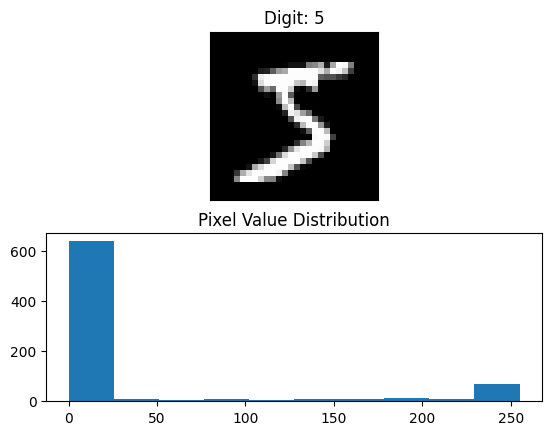

In [3]:
fig = plt.figure()

plt.subplot(2,1,1)
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Digit: {y_train[0]}")
plt.xticks([])
plt.yticks([])

plt.subplot(2,1,2)
plt.hist(x_train[0].reshape(784))
plt.title("Pixel Value Distribution")

plt.show()

Flatten + normalisation

In [4]:
x_train = x_train.reshape(60000, 784).astype("float32") / 255
x_test = x_test.reshape(10000, 784).astype("float32") / 255

Affichage après normalisation

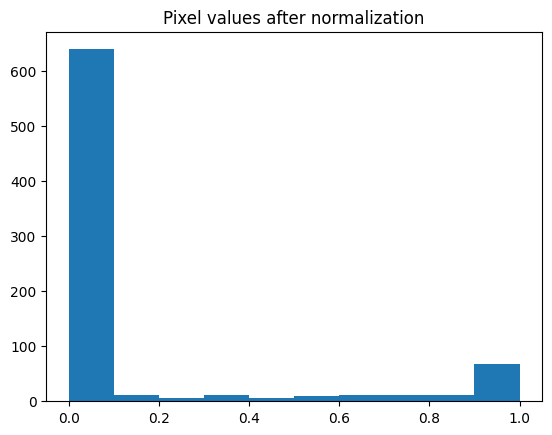

In [5]:
plt.hist(x_train[0])
plt.title("Pixel values after normalization")
plt.show()

One-hot encoding

In [6]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

Modèle MLP (ANN)

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(512, activation='relu', input_shape=(784,)),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compilation + entraînement (SGD)

In [8]:
from tensorflow.keras.optimizers import SGD

model.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8636 - loss: 0.5069 - val_accuracy: 0.9220 - val_loss: 0.2817
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9258 - loss: 0.2658 - val_accuracy: 0.9380 - val_loss: 0.2229
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9401 - loss: 0.2152 - val_accuracy: 0.9481 - val_loss: 0.1913
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9489 - loss: 0.1817 - val_accuracy: 0.9538 - val_loss: 0.1669
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9560 - loss: 0.1570 - val_accuracy: 0.9585 - val_loss: 0.1505
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9618 - loss: 0.1386 - val_accuracy: 0.9623 - val_loss: 0.1391
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9658 - loss: 0.1237 - val_accuracy: 0.9644 - val_loss: 0.1302
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9697 - loss: 0.1113 - val_accu

Évaluation du modèle

In [9]:
loss, accuracy = model.evaluate(x_test, y_test)

print("Loss test:", loss)
print("Accuracy test:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9787 - loss: 0.0747
Loss test: 0.07467997074127197
Accuracy test: 0.9786999821662903
